## Pumpkin Varieties and Color

Load up required libraries and dataset. Convert the data to a dataframe containing a subset of the data: 

Let's look at the relationship between color and variety

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, confusion_matrix, roc_curve, roc_auc_score
import warnings

warnings.filterwarnings("ignore")

In [2]:
full_pumpkins = pd.read_csv("../data/US-pumpkins.csv")
full_pumpkins.head()

,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,...,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
0,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,4/29/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
1,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,5/6/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
2,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
3,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
4,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,11/5/16,90.0,100.0,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


In [3]:
# Select the columns we want to use
columns_to_select = ["City Name", "Package", "Variety", "Origin", "Item Size", "Color"]
pumpkins = full_pumpkins.loc[:, columns_to_select]

In [4]:
# Drop rows with missing values
pumpkins.dropna(inplace=True)

# Print out the first few rows
pumpkins.head()

,City Name,Package,Variety,Origin,Item Size,Color
2,BALTIMORE,24 inch bins,HOWDEN TYPE,DELAWARE,med,ORANGE
3,BALTIMORE,24 inch bins,HOWDEN TYPE,VIRGINIA,med,ORANGE
4,BALTIMORE,24 inch bins,HOWDEN TYPE,MARYLAND,lge,ORANGE
5,BALTIMORE,24 inch bins,HOWDEN TYPE,MARYLAND,lge,ORANGE
6,BALTIMORE,36 inch bins,HOWDEN TYPE,MARYLAND,med,ORANGE


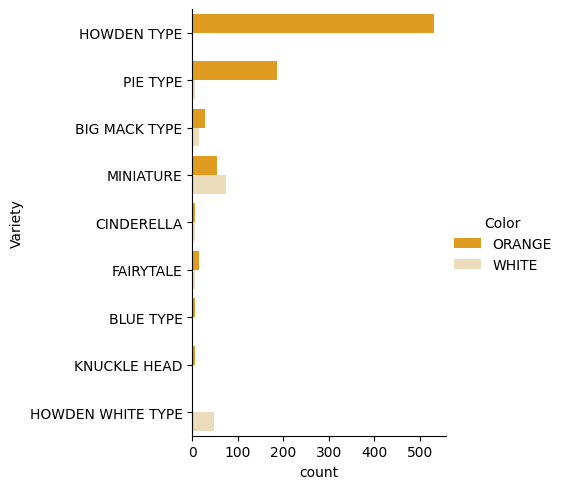

In [5]:
# Specify colors for each value of the 'hue' attribute
palette = {"ORANGE": "orange", "WHITE": "wheat"}

# Plot a bar plot to visualize how many pumpkins of each variety are orange or white
sns.catplot(
    data=pumpkins,
    y="Variety",
    hue="Color",
    kind="count",
    palette=palette,
)

plt.show()

In [6]:
# Let's look at the different values of the 'Item Size' column
pumpkins["Item Size"].unique()

<StringArray>
['med', 'lge', 'sml', 'xlge', 'med-lge', 'jbo', 'exjbo']
Length: 7, dtype: str

In [7]:
# Encode the 'Item Size' column, using ordinal encoding
item_size_categories = [["sml", "med", "med-lge", "lge", "xlge", "jbo", "exjbo"]]
ordinal_features = ["Item Size"]

ordinal_encoder = OrdinalEncoder(categories=item_size_categories)

In [8]:
# Encode all the other features using one-hot encoding
categorical_features = ["City Name", "Package", "Variety", "Origin"]
categorical_encoder = OneHotEncoder(sparse_output=False)

In [9]:
# Add the encoders to a column transformer
ct = ColumnTransformer(
    transformers=[
        ("ord", ordinal_encoder, ordinal_features),
        ("cat", categorical_encoder, categorical_features),
    ]
)

# Get the encoded features as a pandas DataFrame
ct.set_output(transform="pandas")
encoded_features = ct.fit_transform(pumpkins)
encoded_features.head()

,ord__Item Size,cat__City Name_ATLANTA,cat__City Name_BALTIMORE,cat__City Name_BOSTON,cat__City Name_CHICAGO,cat__City Name_COLUMBIA,cat__City Name_DALLAS,cat__City Name_DETROIT,cat__City Name_LOS ANGELES,cat__City Name_MIAMI,...,cat__Origin_MICHIGAN,cat__Origin_NEW JERSEY,cat__Origin_NEW YORK,cat__Origin_NORTH CAROLINA,cat__Origin_OHIO,cat__Origin_PENNSYLVANIA,cat__Origin_TENNESSEE,cat__Origin_TEXAS,cat__Origin_VERMONT,cat__Origin_VIRGINIA
2,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
# Encode the 'Color' column using label encoding
label_encoder = LabelEncoder()
encoded_label = label_encoder.fit_transform(pumpkins["Color"])
encoded_pumpkins = encoded_features.assign(Color=encoded_label)
encoded_pumpkins.head()

,ord__Item Size,cat__City Name_ATLANTA,cat__City Name_BALTIMORE,cat__City Name_BOSTON,cat__City Name_CHICAGO,cat__City Name_COLUMBIA,cat__City Name_DALLAS,cat__City Name_DETROIT,cat__City Name_LOS ANGELES,cat__City Name_MIAMI,...,cat__Origin_NEW JERSEY,cat__Origin_NEW YORK,cat__Origin_NORTH CAROLINA,cat__Origin_OHIO,cat__Origin_PENNSYLVANIA,cat__Origin_TENNESSEE,cat__Origin_TEXAS,cat__Origin_VERMONT,cat__Origin_VIRGINIA,Color
2,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
4,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
5,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
6,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [11]:
# Let's look at the mapping between the encoded values and the original values
list(label_encoder.inverse_transform([0, 1]))

['ORANGE', 'WHITE']

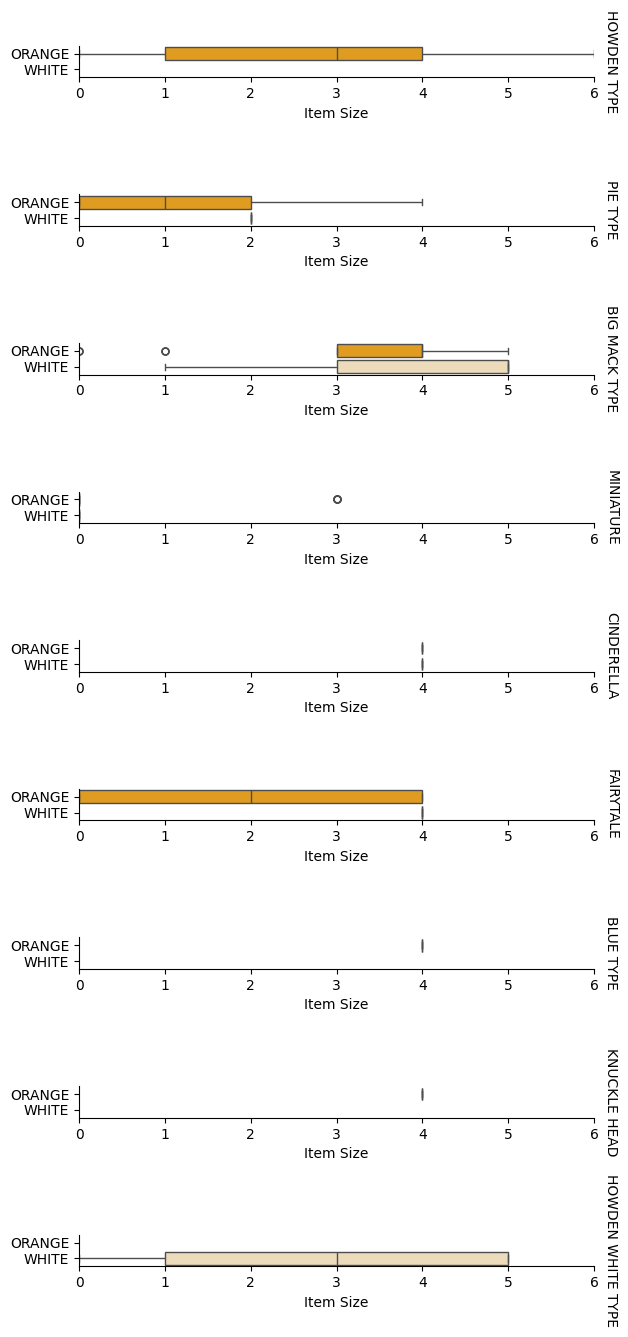

In [12]:
palette = {"ORANGE": "orange", "WHITE": "wheat"}

# We need the encoded 'Item Size' column to use it as the x-axis values in the plot
pumpkins["Item Size"] = encoded_pumpkins["ord__Item Size"]

g = sns.catplot(
    data=pumpkins,
    x="Item Size",
    y="Color",
    row="Variety",
    kind="box",
    orient="h",
    sharex=False,
    margin_titles=True,
    height=1.5,
    aspect=4,
    palette=palette,
)

# Defining axis labels
g.set(xlabel="Item Size", ylabel="").set(xlim=(0, 6))
g.set_titles(row_template="{row_name}")

<Axes: xlabel='Color', ylabel='ord__Item Size'>

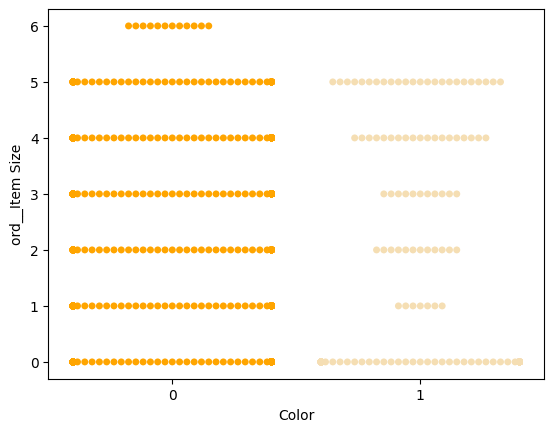

In [13]:
# A swarm plot that shows the distribution of values
palette = {"0": "orange", "1": "wheat"}

sns.swarmplot(
    x="Color",
    y="ord__Item Size",
    data=encoded_pumpkins,
    palette=palette,
)

## Build your Model

In [14]:
# Select the features & the label for the classification model
X = encoded_pumpkins[encoded_pumpkins.columns.difference(["Color"])]
y = encoded_pumpkins["Color"]

# Split the training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [15]:
# Train the model and print out the result
model = LogisticRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

print(classification_report(y_test, predictions))
print(f"Predicted labels: {predictions}\n")
print(f"F1-score: {f1_score(y_test,predictions):.2f}")

              precision    recall  f1-score   support

           0       0.94      0.98      0.96       166
           1       0.85      0.67      0.75        33

    accuracy                           0.92       199
   macro avg       0.89      0.82      0.85       199
weighted avg       0.92      0.92      0.92       199

Predicted labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0
 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 0 1 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 1 1 0
 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 0 0 1 0 0 0 0 0 0 0 0 1 1]

F1-score: 0.75


### Better Comprehension via a Confusion Matrix

In [16]:
cm = confusion_matrix(y_test, predictions)
print(cm)

[[162   4]
 [ 11  22]]


Remember that our labels correspond to:
- 0 : orange
- 1 : white

The rows in the confusion matrix are the actual labels and the columns are the predictions

<table style='width:20vw;'>
    <tr>
        <th></th>
        <th style='text-align:center;'>0</th>
        <th style='text-align:center;'>1</th>
    </tr>
    <tr>
        <th>0</th>
        <td style='text-align:center;background:darkgrey;'>TN</td>
        <td style='text-align:center;'>FP</td>
    </tr>
    <tr>
        <th>1</th>
        <td style='text-align:center;'>FN</td>
        <td style='text-align:center;background:darkgrey;'>TP</td>
    </tr>
</table>

And here is a visual representation of the confusion matrix. It is common to plot a confusion matrix as a heat map, with the shade of each cell reflecting its value.

The diagonal pattern of the darker shades, indicate higher values where the **predicted** and the **actual** values match:

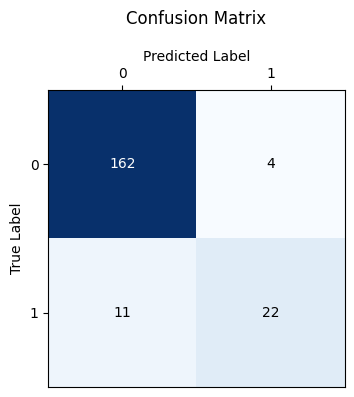

In [17]:
# 1. Create a figure and axes
fig, ax = plt.subplots(figsize=(6, 4))

# 2. Create a heatmap using matplotlib
im = ax.imshow(cm, cmap=plt.cm.Blues, interpolation="nearest")
fig.suptitle("Confusion Matrix")
# fig.colorbar(im)

# 3. Add labels
classes = ["0", "1"]
tick_marks = np.arange(len(classes))
ax.set_xticks(tick_marks, classes)
ax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
ax.set_yticks(tick_marks, classes)

# 4. Add text annotations
thresh = cm.max() / 2.0  # 162 / 2 = 81

for i in range(cm.shape[0]):  # for each row
    for j in range(cm.shape[1]):  # for each column
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            color="white" if cm[i, j] > thresh else "black",
        )

ax.set_ylabel("True Label")
ax.set_xlabel("Predicted Label")
ax.xaxis.set_label_position("top")

plt.tight_layout()
plt.show()

From the confusion matrix we can calculate metrics such as:

- $RECALL = \frac{TP}{TP + FN} = \frac{22}{22 + 11} = 0.67$

- $PRECISION = \frac{TP}{TP + FP} = \frac{22}{22 + 4} = 0.85$

- $f1-score = \frac{2\times PRECISION \times RECALL}{PRECISION + RECALL} = \frac{2 \times 0.85 \times 0.67}{0.85 + 0.67} = 0.75$

## Visualize the ROC Curve of this Model

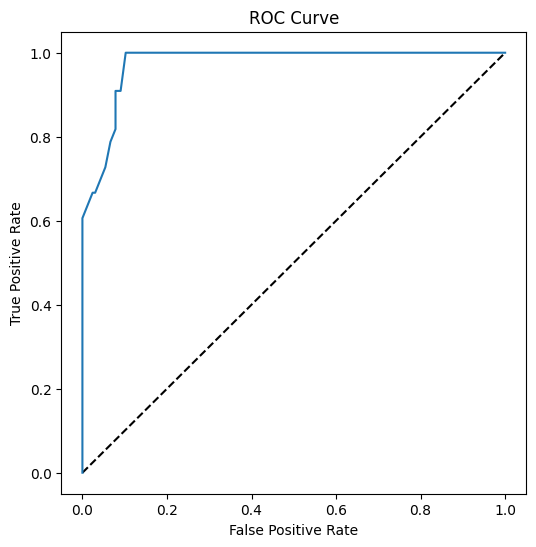

In [18]:
# NOTE: y_scores is a 2-D array of the form:
#       [
#           [0.94, 0.06],
#           [0.91, 0.09],...
#       ]
#       where each entry contains the probability estimates of each
#       of the two labels i.e. label 0, and label 1
y_scores = model.predict_proba(X_test)
# For the roc_curve() function we pass:
# the true binary labels and the probability estimates of the positive class
fpr, tpr, thresholds = roc_curve(y_test, y_scores[:, 1])

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "k--")
ax.plot(fpr, tpr)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve")

plt.show()

In [19]:
# Compute the actual Area-Under-the-Curve (AUC)
auc = roc_auc_score(y_test, y_scores[:, 1])
print(f"{auc:.2f}")

0.97


**Conclusion:** the auc score of 0.97 is pretty good